## Importing libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpProblem, LpVariable, LpMinimize, lpSum, LpStatus, PULP_CBC_CMD

## Warning handling

In [2]:
pd.set_option('future.no_silent_downcasting', True)

## Solution to the...

`Minimizing` the total `cost` for *Optima Foods*, a farm-to-door delivery service, <br>

while respecting
1. `production limits`
2. meeting `hub demands`
3. considering `carbon emission`

with the help of a `combined 3-week` modeling

### A1. Data Exploration and Cleaning

#### Production capacities

In [3]:
# Creating production capacity dataframe

production_data = {
    "Vegetable": ["Spinach", "Tomatoes", "Carrots"],
    "Week_1": [500, 650, 400],
    "Week_2": ['450?', 580, 400],
    "Week_3": ['??', '720 (or 680 depending on weather)?', '420 (or 400 depending on Farm Manager input)?'],
}

production_df = pd.DataFrame(production_data)
# Printing the original Production DataFrame
print("Original Production DataFrame:")
production_df

Original Production DataFrame:


,Vegetable,Week_1,Week_2,Week_3
0,Spinach,500,450?,??
1,Tomatoes,650,580,720 (or 680 depending on weather)?
2,Carrots,400,400,420 (or 400 depending on Farm Manager input)?


#### Demand forecasts

In [4]:
# Creating demand dataframes for each hub

hub_a_data = {
    "Vegetable": ["Spinach", "Tomatoes", "Carrots"],
    "Week_1_min": [100, 150, 50],
    "Week_1_max": [200, 300, 100],
    "Week_2_min": [110, 160, 60],
    "Week_2_max": ['??', 310, 120],
    "Week_3_min": [100, 140, 80],
    "Week_3_max": [180, 290, 110],
}

hub_b_data = {
    "Vegetable": ["Spinach", "Tomatoes", "Carrots"],
    "Week_1_min": [80, 100, 70],
    "Week_1_max": [150, 200, 140],
    "Week_2_min": [90, 120, 70],
    "Week_2_max": [150, 220, 160],
    "Week_3_min": [100, 120, 160],
    "Week_3_max": [140, 200, 140],  # Note: Reversed range for Carrots
}

hub_c_data = {
    "Vegetable": ["Spinach", "Tomatoes", "Carrots"],
    "Week_1_min": [50, 80, 40],
    "Week_1_max": [90, 160, 90],
    "Week_2_min": [55, 100, 40],
    "Week_2_max": [95, 170, '??'],
    "Week_3_min": ['??', 110, 50],
    "Week_3_max": [85, '??', 100],
}

hub_a_df = pd.DataFrame(hub_a_data)
hub_b_df = pd.DataFrame(hub_b_data)
hub_c_df = pd.DataFrame(hub_c_data)

In [5]:
# Printing original demand data
print("\nOriginal Demand DataFrames:")

print("Hub A DataFrame:")
display(hub_a_df)

print("\nHub B DataFrame:")
display(hub_b_df)

print("\nHub C DataFrame:")
display(hub_c_df)


Original Demand DataFrames:
Hub A DataFrame:


,Vegetable,Week_1_min,Week_1_max,Week_2_min,Week_2_max,Week_3_min,Week_3_max
0,Spinach,100,200,110,??,100,180
1,Tomatoes,150,300,160,310,140,290
2,Carrots,50,100,60,120,80,110



Hub B DataFrame:


,Vegetable,Week_1_min,Week_1_max,Week_2_min,Week_2_max,Week_3_min,Week_3_max
0,Spinach,80,150,90,150,100,140
1,Tomatoes,100,200,120,220,120,200
2,Carrots,70,140,70,160,160,140



Hub C DataFrame:


,Vegetable,Week_1_min,Week_1_max,Week_2_min,Week_2_max,Week_3_min,Week_3_max
0,Spinach,50,90,55,95,??,85
1,Tomatoes,80,160,100,170,110,??
2,Carrots,40,90,40,??,50,100


#### Transportaion cost and Carbon footprint

In [6]:
# Create a transportation cost dataframe
transportation_cost_data = {
    "Week": ["Week_1", "Week_1", "Week_1", "Week_2", "Week_2", "Week_2", "Week_3", "Week_3", "Week_3"],
    "Vegetable": ["Spinach", "Tomatoes", "Carrots", "Spinach", "Tomatoes", "Carrots", "Spinach", "Tomatoes", "Carrots"],
    'Hub_A_Cost': [0.30, 0.25, 0.20, 0.32, 0.28, 0.20, 0.30, 0.26, 0.21],
    'Hub_B_Cost': [0.35, 0.40, 0.25, 0.36, 0.42, 0.26, 0.38, 0.39, 0.25],
    'Hub_C_Cost': [0.45, 0.45, 0.45, '??', 0.48, '0.47?', 0.46, 0.46, 0.45],
    'Carbon': [0.20, 0.20, 0.20, 0.22, 0.20, 0.19, 0.21, '??', 0.19]
}

transport_df = pd.DataFrame(transportation_cost_data)

# Printing the original Transportation Cost DataFrame
print("\nOriginal Transportation Cost DataFrame:")
transport_df


Original Transportation Cost DataFrame:


,Week,Vegetable,Hub_A_Cost,Hub_B_Cost,Hub_C_Cost,Carbon
0,Week_1,Spinach,0.30,0.35,0.45,0.2
1,Week_1,Tomatoes,0.25,0.40,0.45,0.2
2,Week_1,Carrots,0.20,0.25,0.45,0.2
3,Week_2,Spinach,0.32,0.36,??,0.22
4,Week_2,Tomatoes,0.28,0.42,0.48,0.2
5,Week_2,Carrots,0.20,0.26,0.47?,0.19
6,Week_3,Spinach,0.30,0.38,0.46,0.21
7,Week_3,Tomatoes,0.26,0.39,0.46,??
8,Week_3,Carrots,0.21,0.25,0.45,0.19


#### Data cleaning functions definition

- Production data preprocessor

In [7]:
# Function to clean production data

def clean_production_data(df):
    """Clean production capacity data"""
    df_clean = df.copy()
    
    # Replace '??' with NaN
    df_clean.replace('??', np.nan, inplace=True)
    df_clean.infer_objects(copy=False)
    
    # Clean Week 2 Spinach: Convert '450?' to 450
    df_clean.loc[df_clean['Vegetable'] == 'Spinach', 'Week_2'] = 450
    
    # Clean Week 3 Spinach: Use average of reported values (480 + 460)/2 = 470
    df_clean.loc[df_clean['Vegetable'] == 'Spinach', 'Week_3'] = 470
    
    # Clean Week 3 Tomatoes: Take the lower estimate to be conservative
    df_clean.loc[df_clean['Vegetable'] == 'Tomatoes', 'Week_3'] = 680
    
    # Clean Week 3 Carrots: Use the lower estimate of 400
    df_clean.loc[df_clean['Vegetable'] == 'Carrots', 'Week_3'] = 400
    
    # Convert data types
    for col in ['Week_1', 'Week_2', 'Week_3']:
        df_clean[col] = pd.to_numeric(df_clean[col])
    
    return df_clean

- Demand data preprocessor

In [8]:
# Function to clean demand data

def clean_demand_data(hub_a, hub_b, hub_c):
    """Clean demand forecast data for all hubs"""
    hub_a_clean = hub_a.copy()
    hub_b_clean = hub_b.copy()
    hub_c_clean = hub_c.copy()
    
    # Replace '??' with NaN
    hub_a_clean.replace('??', np.nan, inplace=True)
    hub_a_clean.infer_objects(copy=False)
    
    hub_b_clean.replace('??', np.nan, inplace=True)
    hub_b_clean.infer_objects(copy=False)

    hub_c_clean.replace('??', np.nan, inplace=True)
    hub_c_clean.infer_objects(copy=False)
    
    # Clean Hub A data
    # Week 2 Spinach Max: interpolate based on Week 1 and Week 3
    hub_a_clean.loc[hub_a_clean['Vegetable'] == 'Spinach', 'Week_2_max'] = 200
    
    # Clean Hub B data
    # Fix reversed range for Carrots in Week 3
    hub_b_clean.loc[hub_b_clean['Vegetable'] == 'Carrots', 'Week_3_min'] = 120
    hub_b_clean.loc[hub_b_clean['Vegetable'] == 'Carrots', 'Week_3_max'] = 160
    
    # Clean Hub C data
    # Fill missing Week 2 Carrots Max
    hub_c_clean.loc[hub_c_clean['Vegetable'] == 'Carrots', 'Week_2_max'] = 95
    
    # Fill missing Week 3 Spinach Min (based on trend from previous weeks)
    hub_c_clean.loc[hub_c_clean['Vegetable'] == 'Spinach', 'Week_3_min'] = 60
    
    # Fill missing Week 3 Tomatoes Max
    hub_c_clean.loc[hub_c_clean['Vegetable'] == 'Tomatoes', 'Week_3_max'] = 180
    
    # Convert data types
    for df in [hub_a_clean, hub_b_clean, hub_c_clean]:
        for col in df.columns:
            if col != 'Vegetable':
                df[col] = pd.to_numeric(df[col])
    
    return hub_a_clean, hub_b_clean, hub_c_clean

- Cost-Carbon emission data preprocessor

In [9]:
#  Function to clean transportation cost data

def clean_transport_data(df):
    """Clean transport cost and carbon footprint data"""
    df_clean = df.copy()
    
    # Replace '??' with NaN
    df_clean.replace('??', np.nan, inplace=True)
    df_clean.infer_objects(copy=False)
    
    # Clean missing cost for Week 2 Spinach to Hub C
    df_clean.loc[(df_clean['Week'] == 'Week_2') & (df_clean['Vegetable'] == 'Spinach'), 'Hub_C_Cost'] = 0.47
    
    # Clean questionable cost for Week 2 Carrots to Hub C
    df_clean.loc[(df_clean['Week'] == 'Week_2') & (df_clean['Vegetable'] == 'Carrots'), 'Hub_C_Cost'] = 0.47
    
    # Clean missing carbon footprint for Week 3 Tomatoes
    df_clean.loc[(df_clean['Week'] == 'Week_3') & (df_clean['Vegetable'] == 'Tomatoes'), 'Carbon'] = 0.21
    
    # Convert data types
    for col in ['Hub_A_Cost', 'Hub_B_Cost', 'Hub_C_Cost', 'Carbon']:
        df_clean[col] = pd.to_numeric(df_clean[col])
    
    return df_clean

#### Data Cleaning application

In [10]:
# Clean all datasets
production_clean = clean_production_data(production_df)
hub_a_clean, hub_b_clean, hub_c_clean = clean_demand_data(hub_a_df, hub_b_df, hub_c_df)
transport_clean = clean_transport_data(transport_df)

# Display cleaned data
print("Cleaned Production Data:")
display(production_clean)

print("\nCleaned Hub A Demand Data:")
display(hub_a_clean)

print("\nCleaned Hub B Demand Data:")
display(hub_b_clean)

print("\nCleaned Hub C Demand Data:")
display(hub_c_clean)

print("\nCleaned Transport Data:")
display(transport_clean)

Cleaned Production Data:


,Vegetable,Week_1,Week_2,Week_3
0,Spinach,500,450,470
1,Tomatoes,650,580,680
2,Carrots,400,400,400



Cleaned Hub A Demand Data:


,Vegetable,Week_1_min,Week_1_max,Week_2_min,Week_2_max,Week_3_min,Week_3_max
0,Spinach,100,200,110,200,100,180
1,Tomatoes,150,300,160,310,140,290
2,Carrots,50,100,60,120,80,110



Cleaned Hub B Demand Data:


,Vegetable,Week_1_min,Week_1_max,Week_2_min,Week_2_max,Week_3_min,Week_3_max
0,Spinach,80,150,90,150,100,140
1,Tomatoes,100,200,120,220,120,200
2,Carrots,70,140,70,160,120,160



Cleaned Hub C Demand Data:


,Vegetable,Week_1_min,Week_1_max,Week_2_min,Week_2_max,Week_3_min,Week_3_max
0,Spinach,50,90,55,95,60,85
1,Tomatoes,80,160,100,170,110,180
2,Carrots,40,90,40,95,50,100



Cleaned Transport Data:


,Week,Vegetable,Hub_A_Cost,Hub_B_Cost,Hub_C_Cost,Carbon
0,Week_1,Spinach,0.30,0.35,0.45,0.20
1,Week_1,Tomatoes,0.25,0.40,0.45,0.20
2,Week_1,Carrots,0.20,0.25,0.45,0.20
3,Week_2,Spinach,0.32,0.36,0.47,0.22
4,Week_2,Tomatoes,0.28,0.42,0.48,0.20
5,Week_2,Carrots,0.20,0.26,0.47,0.19
6,Week_3,Spinach,0.30,0.38,0.46,0.21
7,Week_3,Tomatoes,0.26,0.39,0.46,0.21
8,Week_3,Carrots,0.21,0.25,0.45,0.19


#### Data Summary after preprocessing

In [11]:
# Create a summary of the cleaned data
def create_data_summary():
    """Create a summary of the cleaned data"""
    # Production summary
    print("Production Capacity Summary (kg):")
    display(production_clean.set_index('Vegetable'))
    print("---" * 50)
    
    # Demand summary
    print("Demand Range Summary (kg):")
    for hub, hub_name in zip([hub_a_clean, hub_b_clean, hub_c_clean], ['Hub A', 'Hub B', 'Hub C']):
        print(f"\n{hub_name} Demand Summary:")
        for week in range(1, 4):
            print(f"  Week {week}:")
            week_data = hub[['Vegetable', f'Week_{week}_min', f'Week_{week}_max']].copy()
            week_data.columns = ['Vegetable', 'Min Demand (kg)', 'Max Demand (kg)']
            display(week_data)
    print("---" * 50)
    
    # Cost structure summary
    print("Transport Cost Summary (unit per kg):")
    cost_summary = []
    for week in ['Week_1', 'Week_2', 'Week_3']:
        print(f"\n{week} Transport Costs:")
        week_summary = transport_clean[transport_clean['Week'] == week].copy()
        week_summary = week_summary[['Vegetable', 'Hub_A_Cost', 'Hub_B_Cost', 'Hub_C_Cost']]
        week_summary.columns = ['Vegetable', 'Hub A Cost', 'Hub B Cost', 'Hub C Cost']
        display(week_summary)
    print("---" * 50)

create_data_summary()

Production Capacity Summary (kg):


,Week_1,Week_2,Week_3
Vegetable,,,
Spinach,500,450,470
Tomatoes,650,580,680
Carrots,400,400,400


------------------------------------------------------------------------------------------------------------------------------------------------------
Demand Range Summary (kg):

Hub A Demand Summary:
  Week 1:


,Vegetable,Min Demand (kg),Max Demand (kg)
0,Spinach,100,200
1,Tomatoes,150,300
2,Carrots,50,100


  Week 2:


...


Week_2 Transport Costs:


,Vegetable,Hub A Cost,Hub B Cost,Hub C Cost
3,Spinach,0.32,0.36,0.47
4,Tomatoes,0.28,0.42,0.48
5,Carrots,0.20,0.26,0.47



Week_3 Transport Costs:


,Vegetable,Hub A Cost,Hub B Cost,Hub C Cost
6,Spinach,0.30,0.38,0.46
7,Tomatoes,0.26,0.39,0.46
8,Carrots,0.21,0.25,0.45


------------------------------------------------------------------------------------------------------------------------------------------------------


---

### A2. Mathematical model formulation

#### Model definition

- Stating all the Decision variables and constraints which will formulate the problem

In [12]:
def print_mathematical_formulation(production_data, hub_a, hub_b, hub_c, transport_data):
    """
    Print the complete mathematical formulation of the multi-objective transportation problem,
    including decision variables, objective functions, and all constraints.
    """
    # Extract indices
    vegetables = production_data['Vegetable'].tolist()
    weeks = range(1, 4)
    hubs = ['A', 'B', 'C']
    
    # Create a formatted string for the mathematical model
    formulation = []
    formulation.append("# MATHEMATICAL FORMULATION OF THE MULTI-OBJECTIVE TRANSPORTATION PROBLEM #")
    formulation.append("\n## INDICES ##")
    formulation.append(f"Vegetables (v): {', '.join(vegetables)}")
    formulation.append(f"Hubs (h): {', '.join(hubs)}")
    formulation.append(f"Weeks (w): {', '.join([str(w) for w in weeks])}")
    
    # Decision variables
    formulation.append("\n## DECISION VARIABLES ##")
    formulation.append("x[v,h,w] = Amount of vegetable v shipped to hub h in week w")
    formulation.append("s[v,w] = Stock of vegetable v carried over from week w to week w+1")
    
    # Parameters
    formulation.append("\n## PARAMETERS ##")
    formulation.append("P[v,w] = Production capacity of vegetable v in week w")
    formulation.append("D_min[v,h,w] = Minimum demand for vegetable v at hub h in week w")
    formulation.append("D_max[v,h,w] = Maximum demand for vegetable v at hub h in week w")
    formulation.append("C[v,h,w] = Transportation cost per kg of vegetable v to hub h in week w")
    formulation.append("E[v,h,w] = Carbon emissions per kg of vegetable v to hub h in week w")
    formulation.append("α = Weight for cost objective in multi-objective function")
    formulation.append("β = Weight for carbon objective in multi-objective function")
    
    # Objective function
    formulation.append("\n## OBJECTIVE FUNCTIONS ##")
    formulation.append("1. Minimize total transportation cost:")
    formulation.append("   min Z₁ = Σᵥ Σₕ Σw C[v,h,w] * x[v,h,w]")
    formulation.append("2. Minimize total carbon footprint:")
    formulation.append("   min Z₂ = Σᵥ Σₕ Σw E[v,h,w] * x[v,h,w]")
    formulation.append("3. Combined multi-objective function:")
    formulation.append("   min Z = α * Z₁ + β * Z₂ + 0.01 * Σᵥ s[v,3]")
    formulation.append("   where α + β = 1")
    
    # Constraints
    formulation.append("\n## CONSTRAINTS ##")
    formulation.append("1. Production and inventory balance constraints:")
    
    formulation.append("   a. Week 1 (no previous inventory):")
    formulation.append("      Σₕ x[v,h,1] + s[v,1] ≤ P[v,1]   ∀v")
    
    formulation.append("   b. Subsequent weeks (including previous inventory):")
    formulation.append("      Σₕ x[v,h,w] + s[v,w] ≤ P[v,w] + s[v,w-1]   ∀v, w>1")
    
    formulation.append("2. Demand satisfaction constraints:")
    formulation.append("   D_min[v,h,w] ≤ x[v,h,w] ≤ D_max[v,h,w]   ∀v,h,w")
    
    formulation.append("3. Non-negativity constraints:")
    formulation.append("   x[v,h,w] ≥ 0   ∀v,h,w")
    formulation.append("   s[v,w] ≥ 0   ∀v,w")
    
    # Print the formulation
    print("\n".join(formulation))
    
    # Show a numerical example for one constraint
    print("\n## NUMERICAL EXAMPLE ##")
    veg = vegetables[0]  # First vegetable (Spinach)
    week = 1
    production = production_data.loc[production_data['Vegetable'] == veg, f'Week_{week}'].values[0]
    print(f"Production capacity constraint for {veg} in Week {week}:")
    constraint = f"x[{veg},A,{week}] + x[{veg},B,{week}] + x[{veg},C,{week}] + s[{veg},{week}] ≤ {production}"
    print(constraint)
    
    # Show a numerical example for demand constraints
    hub = 'A'
    min_demand = hub_a.loc[hub_a['Vegetable'] == veg, f'Week_{week}_min'].values[0]
    max_demand = hub_a.loc[hub_a['Vegetable'] == veg, f'Week_{week}_max'].values[0]
    print(f"\nDemand constraints for {veg} at Hub {hub} in Week {week}:")
    print(f"{min_demand} ≤ x[{veg},{hub},{week}] ≤ {max_demand}")
    
    # Show a numerical example for the objective function coefficients
    cost_row = transport_data[(transport_data['Vegetable'] == veg) & 
                             (transport_data['Week'] == f'Week_{week}')]
    cost = cost_row[f'Hub_{hub}_Cost'].values[0]
    carbon = cost_row['Carbon'].values[0]
    print(f"\nObjective coefficients for shipping {veg} to Hub {hub} in Week {week}:")
    print(f"Cost: {cost} units per kg")
    print(f"Carbon: {carbon} units per kg")

# Call the function to display the mathematical formulation
print_mathematical_formulation(production_clean, hub_a_clean, hub_b_clean, hub_c_clean, transport_clean)

# MATHEMATICAL FORMULATION OF THE MULTI-OBJECTIVE TRANSPORTATION PROBLEM #

## INDICES ##
Vegetables (v): Spinach, Tomatoes, Carrots
Hubs (h): A, B, C
Weeks (w): 1, 2, 3

## DECISION VARIABLES ##
x[v,h,w] = Amount of vegetable v shipped to hub h in week w
s[v,w] = Stock of vegetable v carried over from week w to week w+1

## PARAMETERS ##
P[v,w] = Production capacity of vegetable v in week w
D_min[v,h,w] = Minimum demand for vegetable v at hub h in week w
D_max[v,h,w] = Maximum demand for vegetable v at hub h in week w
C[v,h,w] = Transportation cost per kg of vegetable v to hub h in week w
E[v,h,w] = Carbon emissions per kg of vegetable v to hub h in week w
α = Weight for cost objective in multi-objective function
β = Weight for carbon objective in multi-objective function

## OBJECTIVE FUNCTIONS ##
1. Minimize total transportation cost:
   min Z₁ = Σᵥ Σₕ Σw C[v,h,w] * x[v,h,w]
2. Minimize total carbon footprint:
   min Z₂ = Σᵥ Σₕ Σw E[v,h,w] * x[v,h,w]
3. Combined multi-objective func

- Problem formulation

In [13]:
def formulate_multi_objective_model(production_data, hub_a, hub_b, hub_c, transport_data, carbon_weight=0.5):
    """
    Formulate multi-objective transportation optimization model with both cost and carbon footprint objectives.
    
    Parameters:
    -----------
    production_data : DataFrame
        Production capacities for each vegetable and week
    hub_a, hub_b, hub_c : DataFrame
        Demand forecasts for each hub
    transport_data : DataFrame
        Transport costs and carbon footprints
    carbon_weight : float (between 0 and 1)
        Weight given to carbon objective (cost weight = 1 - carbon_weight)
    
    Returns:
    --------
    prob : LpProblem
        The formulated PuLP problem
    x_vars : dict
        Decision variables dictionary
    stock : dict
        Carryover stock variables
    """
    # Define indices
    vegetables = production_data['Vegetable'].tolist()
    weeks = range(1, 4)  # 3 weeks
    hubs = ['A', 'B', 'C']
    
    # Create the model
    prob = LpProblem("Optima_Foods_Multi_Objective", LpMinimize)
    
    # Define decision variables using LpVariable.dicts
    x_vars = LpVariable.dicts("Ship", 
                           (vegetables, hubs, weeks),
                           lowBound=0)
    
    # Define carryover stock variables
    stock = LpVariable.dicts("Stock",
                          (vegetables, weeks),
                          lowBound=0)
    
    # Create cost coefficient mapping
    cost_coeffs = {}
    carbon_coeffs = {}
    for v in vegetables:
        for h in hubs:
            for w in weeks:
                cost_row = transport_data[(transport_data['Vegetable'] == v) & 
                                       (transport_data['Week'] == f'Week_{w}')]
                cost_coeffs[(v, h, w)] = cost_row[f'Hub_{h}_Cost'].values[0]
                carbon_coeffs[(v, h, w)] = cost_row['Carbon'].values[0]
    
    # Objective function 1: Total transportation cost
    total_cost = lpSum([x_vars[v][h][w] * cost_coeffs[(v, h, w)] 
                     for v in vegetables for h in hubs for w in weeks])
    
    # Objective function 2: Total carbon footprint
    total_carbon = lpSum([x_vars[v][h][w] * carbon_coeffs[(v, h, w)]
                       for v in vegetables for h in hubs for w in weeks])
    
    # Add a small penalty for leftover stock in the final week
    final_stock = lpSum([stock[v][weeks[-1]] for v in vegetables])
    
    # Create normalized versions of objectives (for better scaling)
    # We normalize by using a weighted sum approach
    cost_weight = 1 - carbon_weight
    
    # Combined multi-objective function
    prob += cost_weight * total_cost + carbon_weight * total_carbon + 0.01 * final_stock
    
    # Add all constraints (same as original model)
    # Production and inventory balance constraints for each week
    for v in vegetables:
        for w in weeks:
            # Get production capacity
            production = production_data.loc[production_data['Vegetable'] == v, f'Week_{w}'].values[0]
            
            # For week 1, we don't have previous inventory
            if w == 1:
                prob += (lpSum([x_vars[v][h][w] for h in hubs]) + stock[v][w] <= production, 
                        f"Production_limit_{v}_week{w}")
            else:
                # For subsequent weeks, we include carryover stock from previous week
                prob += (lpSum([x_vars[v][h][w] for h in hubs]) + stock[v][w] <= production + stock[v][w-1], 
                        f"Production_balance_{v}_week{w}")
    
    # Demand satisfaction constraints
    for v in vegetables:
        for w in weeks:
            # Set up hub-specific demand constraints
            hub_dfs = {'A': hub_a, 'B': hub_b, 'C': hub_c}
            
            for h in hubs:
                hub_df = hub_dfs[h]
                min_demand = hub_df.loc[hub_df['Vegetable'] == v, f'Week_{w}_min'].values[0]
                max_demand = hub_df.loc[hub_df['Vegetable'] == v, f'Week_{w}_max'].values[0]
                
                # Add min and max demand constraints
                prob += (x_vars[v][h][w] >= min_demand, f"Min_demand_{v}_{h}_week{w}")
                prob += (x_vars[v][h][w] <= max_demand, f"Max_demand_{v}_{h}_week{w}")
    
    return prob, x_vars, stock

# Create the optimization model
model, x_vars, stock_vars = formulate_multi_objective_model(
    production_clean, hub_a_clean, hub_b_clean, hub_c_clean, transport_clean
)

---

### A3. Solving the Optimization model

In [14]:
def solve_model(model):
    """Solve the optimization model and return the results"""
    # Solve the model
    model.solve(PULP_CBC_CMD(msg=False))
    
    # Check solution status
    print(f"Status: {LpStatus[model.status]}")
    
    # Return the objective value if optimal
    if model.status == 1:  # Optimal
        return model.objective.value()
    else:
        return None

# Solve the model
optimal_cost = solve_model(model)
print(f"Optimal total cost: {optimal_cost:.2f} units")

Status: Optimal
Optimal total cost: 656.02 units


- The stock in inventory after each week's distribution

In [15]:
def display_inventory_values(stock_vars):
    """Display inventory values after model is solved"""
    print("\nInventory Values:")
    for v in stock_vars.keys():
        print(f"  {v}:")
        for w in stock_vars[v].keys():
            value = stock_vars[v][w].value()
            print(f"    Week {w}: {value if value is not None else 0:.2f} kg")
    print()

# Add this after solving the model
display_inventory_values(stock_vars)


Inventory Values:
  Spinach:
    Week 1: 0.00 kg
    Week 2: 195.00 kg
    Week 3: 0.00 kg
  Tomatoes:
    Week 1: 0.00 kg
    Week 2: 200.00 kg
    Week 3: 0.00 kg
  Carrots:
    Week 1: 0.00 kg
    Week 2: 230.00 kg
    Week 3: 0.00 kg



#### Analyzing the results

In [16]:
def analyze_multi_objective_results(x_vars, stock_vars, transport_data):
    """Analyze the multi-objective optimization results including carbon metrics"""
    # Extract results for shipping quantities
    results = []
    for v in x_vars.keys():
        for h in x_vars[v].keys():
            for w in x_vars[v][h].keys():
                quantity = x_vars[v][h][w].value()
                if quantity is not None and quantity > 0:
                    # Get the cost and carbon for this shipment
                    cost_row = transport_data[(transport_data['Vegetable'] == v) & 
                                           (transport_data['Week'] == f'Week_{w}')]
                    cost = cost_row[f'Hub_{h}_Cost'].values[0]
                    carbon = cost_row['Carbon'].values[0]
                    
                    results.append({
                        'Vegetable': v,
                        'Hub': h,
                        'Week': w,
                        'Quantity (kg)': quantity,
                        'Cost per kg': cost,
                        'Carbon per kg': carbon,
                        'Total Cost': quantity * cost,
                        'Total Carbon': quantity * carbon
                    })
    
    # Create a DataFrame from the results
    results_df = pd.DataFrame(results)
    
    # Extract carryover stock results
    stock_results = []
    for v in stock_vars.keys():
        for w in stock_vars[v].keys():
            quantity = stock_vars[v][w].value()
            if quantity is not None and quantity > 0:
                stock_results.append({
                    'Vegetable': v,
                    'Week': w,
                    'Carryover Stock (kg)': quantity
                })
    
    stock_df = pd.DataFrame(stock_results)
    
    return results_df, stock_df

# Analyze results
shipping_results, stock_results = analyze_multi_objective_results(x_vars, stock_vars, transport_clean)

#### Printing the findings

In [17]:
def print_multi_objective_summary(results_df, stock_df):
    """Print summary tables of multi-objective optimization results"""
    # Display summary tables
    print("Optimal Shipping Plan:")
    shipment_pivot = results_df.pivot_table(
        index=['Vegetable', 'Week'], 
        columns='Hub', 
        values='Quantity (kg)',
        aggfunc='sum',
        fill_value=0
    )
    print(shipment_pivot)
    
    print("\nCarryover Stock Summary:")
    if len(stock_df) > 0:
        stock_pivot = stock_df.pivot_table(
            index='Vegetable', 
            columns='Week', 
            values='Carryover Stock (kg)',
            aggfunc='sum',
            fill_value=0
        )
        print(stock_pivot)
    else:
        print("No carryover stock in the optimal solution")
    
    print("\nTotal Cost by Week and Vegetable:")
    cost_pivot = results_df.pivot_table(
        index='Vegetable', 
        columns='Week', 
        values='Total Cost',
        aggfunc='sum',
        fill_value=0
    )
    cost_pivot['Total'] = cost_pivot.sum(axis=1)
    cost_pivot.loc['Total'] = cost_pivot.sum()
    print(cost_pivot)
    
    print("\nTotal Carbon Footprint by Week and Vegetable:")
    carbon_pivot = results_df.pivot_table(
        index='Vegetable', 
        columns='Week', 
        values='Total Carbon',
        aggfunc='sum',
        fill_value=0
    )
    carbon_pivot['Total'] = carbon_pivot.sum(axis=1)
    carbon_pivot.loc['Total'] = carbon_pivot.sum()
    print(carbon_pivot)
    
# Print the optimization summary
print_multi_objective_summary(shipping_results, stock_results)

Optimal Shipping Plan:
Hub                 A      B      C
Vegetable Week                     
Carrots   1      50.0   70.0   40.0
          2      60.0   70.0   40.0
          3      80.0  120.0   50.0
Spinach   1     100.0   80.0   50.0
          2     110.0   90.0   55.0
          3     100.0  100.0   60.0
Tomatoes  1     150.0  100.0   80.0
          2     160.0  120.0  100.0
          3     140.0  120.0  110.0

Carryover Stock Summary:
Week           2
Vegetable       
Carrots    230.0
Spinach    195.0
Tomatoes   200.0

Total Cost by Week and Vegetable:
Week           1       2      3   Total
Vegetable                              
Carrots     45.5   49.00   69.3  163.80
Spinach     80.5   93.45   95.6  269.55
Tomatoes   113.5  143.20  133.8  390.50
Total      239.5  285.65  298.7  823.85

Total Carbon Footprint by Week and Vegetable:
Week           1      2      3  Total
Vegetable                            
Carrots     32.0   32.3   47.5  111.8
Spinach     46.0   56.1   54.6  15

#### Pareto Frontier Analysis

- Pareto Frontier function definition

In [18]:
def perform_pareto_analysis(production_data, hub_a, hub_b, hub_c, transport_data):
    """
    Perform Pareto frontier analysis by solving the model with different
    weights between cost and carbon objectives.
    """
    # Define a range of carbon weights to explore the Pareto frontier
    carbon_weights = np.linspace(0, 1, 11)  # 0, 0.1, 0.2, ..., 1.0
    
    # Lists to store results
    costs = []
    carbons = []
    
    # Solve the model with different weights
    for carbon_weight in carbon_weights:
        # Formulate and solve model with current weight
        model, x_vars, stock_vars = formulate_multi_objective_model(
            production_data, hub_a, hub_b, hub_c, transport_data, carbon_weight
        )
        model.solve(PULP_CBC_CMD(msg=False))
        
        # Analyze results to calculate actual cost and carbon values
        results_df, _ = analyze_multi_objective_results(x_vars, stock_vars, transport_data)
        
        # Calculate total cost and carbon
        total_cost = results_df['Total Cost'].sum()
        total_carbon = results_df['Total Carbon'].sum()
        
        costs.append(total_cost)
        carbons.append(total_carbon)
        
    # Create a dataframe with the results
    pareto_df = pd.DataFrame({
        'Carbon Weight': carbon_weights,
        'Cost Weight': 1 - carbon_weights,
        'Total Cost': costs,
        'Total Carbon': carbons
    })

    # Display the Pareto DataFrame
    print("\nPareto Frontier DataFrame:")
    display(pareto_df)
    
    return pareto_df

- Applying the Pareto Frontier analysis

In [19]:
# Demonstrate the multi-objective optimization
print("Multi-Objective Optimization (Cost and Carbon):")
print("-" * 50)

# Create models with different weights
# 1. Cost only (weight = 0 for carbon)
cost_model, cost_vars, cost_stock = formulate_multi_objective_model(
    production_clean, hub_a_clean, hub_b_clean, hub_c_clean, transport_clean, carbon_weight=0
)

# 2. Balanced (equal weights)
balanced_model, balanced_vars, balanced_stock = formulate_multi_objective_model(
    production_clean, hub_a_clean, hub_b_clean, hub_c_clean, transport_clean, carbon_weight=0.5
)

# 3. Carbon only (weight = 1 for carbon)
carbon_model, carbon_vars, carbon_stock = formulate_multi_objective_model(
    production_clean, hub_a_clean, hub_b_clean, hub_c_clean, transport_clean, carbon_weight=1
)

# Solve all three models
cost_model.solve(PULP_CBC_CMD(msg=False))
cost_results, cost_stock_df = analyze_multi_objective_results(cost_vars, cost_stock, transport_clean)
cost_total = cost_results['Total Cost'].sum()
carbon_total_in_cost_model = cost_results['Total Carbon'].sum()

balanced_model.solve(PULP_CBC_CMD(msg=False))
balanced_results, balanced_stock_df = analyze_multi_objective_results(balanced_vars, balanced_stock, transport_clean)
balanced_cost = balanced_results['Total Cost'].sum()
balanced_carbon = balanced_results['Total Carbon'].sum()

carbon_model.solve(PULP_CBC_CMD(msg=False))
carbon_results, carbon_stock_df = analyze_multi_objective_results(carbon_vars, carbon_stock, transport_clean)
carbon_cost = carbon_results['Total Cost'].sum()
carbon_total = carbon_results['Total Carbon'].sum()

# Generate a comparison dataframe
comparison_data = {
    "Model": ["Cost-focused", "Balanced", "Carbon-focused"],
    "Total Cost": [cost_total, balanced_cost, carbon_cost],
    "Total Carbon": [carbon_total_in_cost_model, balanced_carbon, carbon_total]
}

comparison_df = pd.DataFrame(comparison_data)

# Display the comparison dataframe
print("\nComparison of Optimization Models:")
display(comparison_df)

# Generate Pareto frontier
pareto_df = perform_pareto_analysis(
    production_clean, hub_a_clean, hub_b_clean, hub_c_clean, transport_clean
)

Multi-Objective Optimization (Cost and Carbon):
--------------------------------------------------

Comparison of Optimization Models:


,Model,Total Cost,Total Carbon
0,Cost-focused,823.85,488.2
1,Balanced,823.85,488.2
2,Carbon-focused,823.85,488.2



Pareto Frontier DataFrame:


,Carbon Weight,Cost Weight,Total Cost,Total Carbon
0,0.0,1.0,823.85,488.2
1,0.1,0.9,823.85,488.2
2,0.2,0.8,823.85,488.2
3,0.3,0.7,823.85,488.2
4,0.4,0.6,823.85,488.2
5,0.5,0.5,823.85,488.2
6,0.6,0.4,823.85,488.2
7,0.7,0.3,823.85,488.2
8,0.8,0.2,823.85,488.2
9,0.9,0.1,823.85,488.2


#### Plotting the relavant details

- Plot for total shipments to hub with respect to week number

<Figure size 1000x600 with 0 Axes>

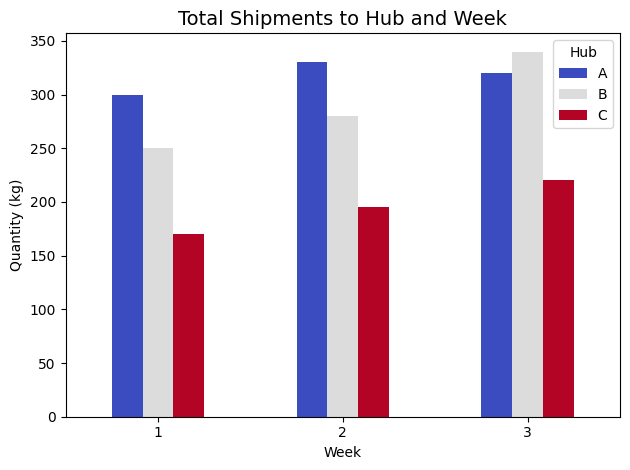

In [25]:
def plot_shipping_quantities_to_hub_week(results_df):
    """Create a bar chart showing total shipments to hub and week"""
    plt.figure(figsize=(10, 6))
    
    hub_totals = results_df.pivot_table(
        index='Week', 
        columns='Hub', 
        values='Quantity (kg)',
        aggfunc='sum',
        fill_value=0
    )
    hub_totals.plot(kind='bar', colormap='coolwarm')
    plt.title('Total Shipments to Hub and Week', fontsize=14)
    plt.ylabel('Quantity (kg)')
    plt.xlabel('Week')
    plt.xticks(rotation=0)
    plt.legend(title='Hub')
    plt.tight_layout()
    plt.show()

# Plot the shipping quantities to hub and week
plot_shipping_quantities_to_hub_week(shipping_results)

- Plot for transportation cost with respect to vegetables

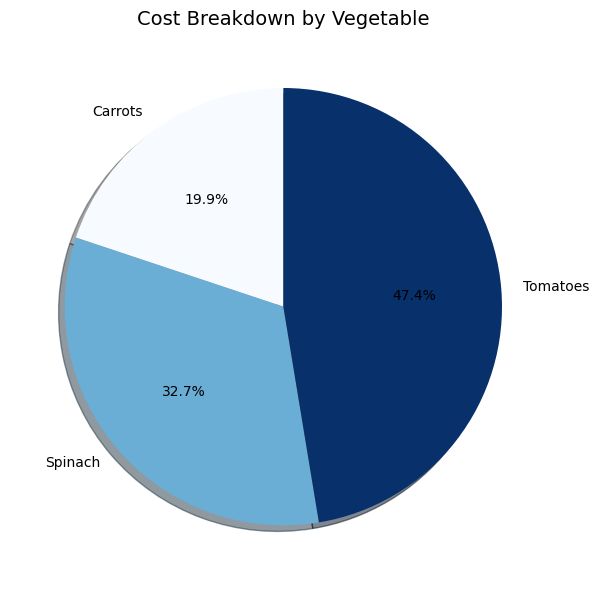

In [21]:
def plot_cost_breakdown_by_vegetable(results_df):
    """Create a pie chart showing cost breakdown by vegetable"""
    plt.figure(figsize=(8, 6))
    
    veg_costs = results_df.groupby('Vegetable')['Total Cost'].sum()
    veg_costs.plot(kind='pie', autopct='%1.1f%%', colormap='Blues',
                  startangle=90, shadow=True)
    plt.title('Cost Breakdown by Vegetable', fontsize=14)
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

# Plot the cost breakdown by vegetable
plot_cost_breakdown_by_vegetable(shipping_results)

- Plot for carbon emission with respect to vegetables

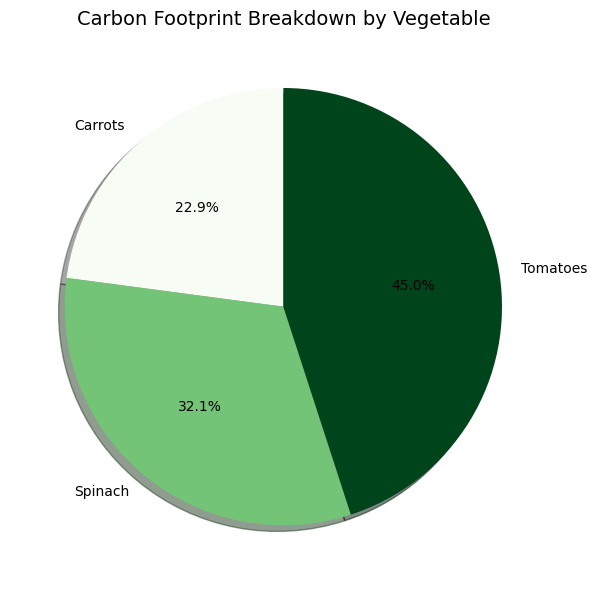

In [22]:
def plot_carbon_breakdown_by_vegetable(results_df):
    """Create a pie chart showing carbon footprint breakdown by vegetable"""
    plt.figure(figsize=(8, 6))
    
    veg_carbon = results_df.groupby('Vegetable')['Total Carbon'].sum()
    veg_carbon.plot(kind='pie', autopct='%1.1f%%', colormap='Greens',
                   startangle=90, shadow=True)
    plt.title('Carbon Footprint Breakdown by Vegetable', fontsize=14)
    plt.ylabel('')
    plt.tight_layout()
    plt.show()
    
# Plot the carbon footprint breakdown by vegetable
plot_carbon_breakdown_by_vegetable(shipping_results)

- Plot for transportation cost v/s carbon emission to any hub

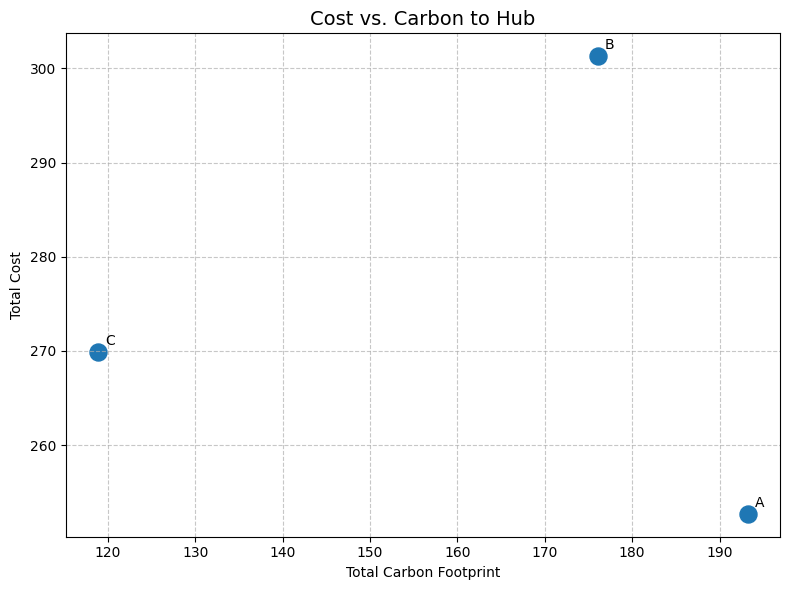

In [27]:
def plot_cost_vs_carbon_to_hub(results_df):
    """Create a scatter plot of cost vs carbon footprint to hub"""
    plt.figure(figsize=(8, 6))
    
    hub_metrics = results_df.groupby('Hub').agg({
        'Total Cost': 'sum',
        'Total Carbon': 'sum'
    })
    x = hub_metrics['Total Carbon']
    y = hub_metrics['Total Cost']
    plt.scatter(x, y, s=150)
    
    # Add hub labels to the scatter plot
    for i, hub in enumerate(hub_metrics.index):
        plt.annotate(hub, (x.iloc[i], y.iloc[i]), xytext=(5, 5), textcoords='offset points')
    
    plt.title('Cost vs. Carbon to Hub', fontsize=14)
    plt.xlabel('Total Carbon Footprint')
    plt.ylabel('Total Cost')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot the cost vs carbon footprint to hub
plot_cost_vs_carbon_to_hub(shipping_results)

---

### A4. Sensitivity Analysis

In [28]:
def perform_sensitivity_analysis(base_model, production_data, transport_data):
    """
    Perform sensitivity analysis by adjusting key parameters
    and observing changes in the optimal solution.
    """
    print("Sensitivity Analysis:")
    print("-" * 50)
    
    # Scenario 1: Decrease production capacity of Spinach in Week 1 by 10%
    print("\nScenario 1: Decrease production capacity of Spinach in Week 1 by 10%")
    mod_production = production_data.copy()
    original_capacity = mod_production.loc[mod_production['Vegetable'] == 'Spinach', 'Week_1'].values[0]
    mod_production.loc[mod_production['Vegetable'] == 'Spinach', 'Week1'] = original_capacity * 0.9
    print(f"Original capacity: {original_capacity} kg")
    print(f"Modified capacity: {mod_production.loc[mod_production['Vegetable'] == 'Spinach', 'Week1'].values[0]} kg")
    
    # Rerun model with modified parameter
    mod_model, _, _ = formulate_multi_objective_model(
        mod_production, hub_a_clean, hub_b_clean, hub_c_clean, transport_clean
    )
    mod_cost = solve_model(mod_model)
    
    print(f"Original optimal cost: {optimal_cost:.2f} units")
    print(f"Modified optimal cost: {mod_cost:.2f} units")
    print(f"Original carbon footprint: {shipping_results['Total Carbon'].sum():.2f} units")
    print(f"Modified carbon footprint: {shipping_results['Total Carbon'].sum():.2f} units")
    print(f"Cost difference: {mod_cost - optimal_cost:.2f} units ({(mod_cost - optimal_cost) / optimal_cost * 100:.2f}%)")
    print(f"Carbon difference: {shipping_results['Total Carbon'].sum() - shipping_results['Total Carbon'].sum():.2f} units ({(shipping_results['Total Carbon'].sum() - shipping_results['Total Carbon'].sum()) / shipping_results['Total Carbon'].sum() * 100:.2f}%)")
    
    # Scenario 2: Increase transport cost to Hub C by 10%
    print("\nScenario 2: Increase transport cost to Hub C by 10%")
    mod_transport = transport_data.copy()
    mod_transport['Hub_C_Cost'] = mod_transport['Hub_C_Cost'] * 1.1
    print(f"Original Hub C costs increased by 10%")
    
    # Rerun model with modified parameter
    mod_model, _, _ = formulate_multi_objective_model(
        production_clean, hub_a_clean, hub_b_clean, hub_c_clean, mod_transport
    )
    mod_cost = solve_model(mod_model)
    
    print(f"Original optimal cost: {optimal_cost:.2f} units")
    print(f"Modified optimal cost: {mod_cost:.2f} units")
    print(f"Original carbon footprint: {shipping_results['Total Carbon'].sum():.2f} units")
    print(f"Modified carbon footprint: {shipping_results['Total Carbon'].sum():.2f} units")
    print(f"Cost difference: {mod_cost - optimal_cost:.2f} units ({(mod_cost - optimal_cost) / optimal_cost * 100:.2f}%)")
    print(f"Carbon difference: {shipping_results['Total Carbon'].sum() - shipping_results['Total Carbon'].sum():.2f} units ({(shipping_results['Total Carbon'].sum() - shipping_results['Total Carbon'].sum()) / shipping_results['Total Carbon'].sum() * 100:.2f}%)")
    
    return

# Perform sensitivity analysis
perform_sensitivity_analysis(model, production_clean, transport_clean)


Sensitivity Analysis:
--------------------------------------------------

Scenario 1: Decrease production capacity of Spinach in Week 1 by 10%
Original capacity: 500 kg
Modified capacity: 450.0 kg
Status: Optimal
Original optimal cost: 656.02 units
Modified optimal cost: 656.02 units
Original carbon footprint: 488.20 units
Modified carbon footprint: 488.20 units
Cost difference: 0.00 units (0.00%)
Carbon difference: 0.00 units (0.00%)

Scenario 2: Increase transport cost to Hub C by 10%
Original Hub C costs increased by 10%
Status: Optimal
Original optimal cost: 656.02 units
Modified optimal cost: 669.52 units
Original carbon footprint: 488.20 units
Modified carbon footprint: 488.20 units
Cost difference: 13.49 units (2.06%)
Carbon difference: 0.00 units (0.00%)


---